In [1]:
import zipfile
path = zipfile.ZipFile("/content/archive (5).zip")
path.extractall("CAT_AND_DOG_CLASSIFICATION")

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
   "/content/CAT_AND_DOG_CLASSIFICATION/training_set",
    image_size = (128, 128),
    batch_size=32,
    subset = "training",
    validation_split = 0.2,
    seed = 42

)

Found 8005 files belonging to 1 classes.
Using 6404 files for training.


In [5]:
test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/CAT_AND_DOG_CLASSIFICATION/test_set",
    image_size = (128, 128),
    batch_size=32,
    subset = "validation",
    validation_split = 0.2,
    seed = 42

)

Found 2023 files belonging to 1 classes.
Using 404 files for validation.


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2   # open cv

In [8]:
cv2.imread("/content/test_set/test_set/cats/cat.4004.jpg")

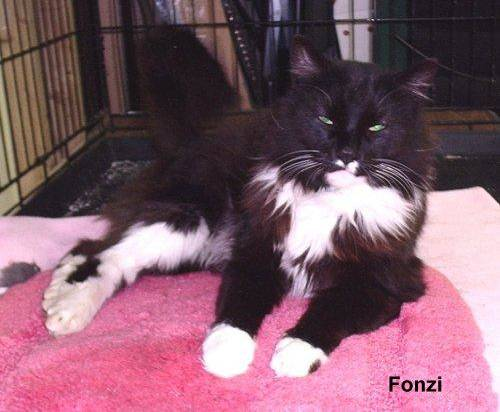

In [ ]:
Image.open("/content/test_set/test_set/cats/cat.4010.jpg")

array([[[249, 223, 216],
        [247, 221, 214],
        [218, 192, 185],
        ...,
        [204, 187, 190],
        [197, 180, 183],
        [103,  86,  89]],

       [[196, 170, 163],
        [202, 176, 169],
        [186, 160, 153],
        ...,
        [205, 188, 191],
        [198, 181, 184],
        [104,  87,  90]],

       [[134, 108, 101],
        [150, 124, 117],
        [150, 124, 117],
        ...,
        [207, 190, 193],
        [201, 184, 187],
        [107,  90,  93]],

       ...,

       [[ 66,  80,  78],
        [ 74,  88,  86],
        [ 86, 100,  98],
        ...,
        [ 76,  90,  88],
        [ 55,  68,  66],
        [ 34,  48,  46]],

       [[ 92, 106, 104],
        [ 98, 112, 110],
        [106, 120, 118],
        ...,
        [ 68,  81,  79],
        [ 54,  65,  63],
        [ 37,  50,  48]],

       [[ 56,  70,  68],
        [ 59,  73,  71],
        [ 64,  78,  76],
        ...,
        [  1,  12,  10],
        [  0,   1,   0],
        [  0,   2,   0]]], dtype=uint8)
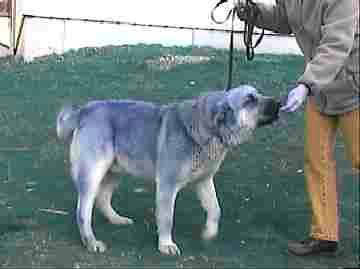

In [9]:
cv2.imread('/content/CAT_AND_DOG_CLASSIFICATION/training_set/training_set/dogs/dog.1010.jpg')

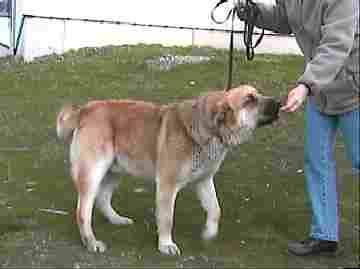

In [10]:
Image.open("/content/CAT_AND_DOG_CLASSIFICATION/training_set/training_set/dogs/dog.1010.jpg")

In [11]:
train_data.class_names

['training_set']

In [ ]:
##  CNN

 **CNN**

In [42]:
model = keras.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.MaxPooling2D((2,2)),


    layers.Conv2D(128, (3, 3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
])

In [43]:
model.compile(optimizer="adam",loss = "binary_crossentropy", metrics=["accuracy"])

In [44]:
model.fit(train_data , epochs=5, validation_data=test_data)

Epoch 1/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [62]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import gradio  as gr

def pred_img(img):
  img = img_to_array(img)
  img = img/255.0
  img = np.expand_dims(img, axis = 0)
  pred = model.predict(img)[0][0]
  if pred>=0.5:
    print("Dog")
  else:
    print("cat")

open = gr.Interface(fn =pred_img , inputs = , outputs="text")
open.launch()

TypeError: array() got an unexpected keyword argument 'filepaths'